# Turan RL Training — NaiveTrainingV2
### upper-triangle bool obs · bfloat16 autocast · torch.compile

In [6]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import torch
import numpy as np
import matplotlib.pyplot as plt

from turan_env_c import CEnv, CHECKER_C4, CHECKER_C3, CHECKER_K4
from policy import MLPActorCritic
from ppo3 import CFG, load_checkpoint, run_episodes

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")

torch 2.10.0+cu130  cuda=True
  NVIDIA GeForce RTX 5090


## Env sanity check

In [7]:
N = 20
env = CEnv(n=N, num_envs=4, checker_id=CHECKER_C4)

obs = env.reset()
print(f"obs shape : {obs.shape}   dtype: {obs.dtype}")
print(f"num_actions: {env.num_actions}  (= {N}*{N-1}/2)")
print(f"expected   : {N*(N-1)//2}")

# take a few random steps
actions = np.random.randint(0, env.num_actions, env.num_envs)
obs2, rew, done = env.step(actions)
print(f"\nafter 1 step:")
print(f"  obs dtype={obs2.dtype}  any_done={done.any()}  rewards={rew}")

env.close()

obs shape : (4, 190)   dtype: bool
num_actions: 190  (= 20*19/2)
expected   : 190

after 1 step:
  obs dtype=bool  any_done=False  rewards=[-0.01 -0.01 -0.01 -0.01]


## Benchmark env throughput

In [8]:
bench_env = CEnv(n=20, num_envs=1024, checker_id=CHECKER_C4)
bench_env.benchmark(steps=500)
bench_env.close()

500 steps x 1024 envs in 0.20s
  2,578,250 steps/sec
  2.58M steps/sec


## Config

In [9]:
cfg = {**CFG}   # copy defaults, override below if needed

# cfg['n']             = 20
# cfg['num_envs']      = 1024
# cfg['checker_id']    = CHECKER_C4
# cfg['total_steps']   = 20_000_000
# cfg['lr']            = 3e-4
# cfg['checkpoint_dir']= './checkpoints'

for k, v in cfg.items():
    print(f"  {k:20s} = {v}")

  n                    = 20
  num_envs             = 1024
  checker_id           = 1
  n_steps              = 64
  n_epochs             = 10
  batch_size           = 2048
  lr                   = 0.0003
  gamma                = 0.99
  gae_lambda           = 0.95
  clip_eps             = 0.2
  vf_coef              = 0.5
  ent_coef             = 0.01
  max_grad_norm        = 0.5
  total_steps          = 20000000
  device               = cuda
  log_interval         = 10
  save_interval        = 100
  checkpoint_dir       = ./checkpoints


## Train

In [10]:
from ppo3 import train

RESUME = None  # e.g. './checkpoints/best.pt'

policy, history = train(cfg=cfg, resume=RESUME)


PPO  n=20  envs=1024  checker=1  device=cuda
transitions/update: 65,536   total iters: 305
params: 278,463

200 steps x 1024 envs in 0.02s
  8,946,637 steps/sec
  8.95M steps/sec
iter    10 | steps 0.66M | fps 31,765 | ret 16.44 | best 16.44 | pg -0.0464 | vf 3.507 | ent 5.052 | clip 0.184 | t 20s
iter    20 | steps 1.31M | fps 31,754 | ret 17.67 | best 17.67 | pg -0.0513 | vf 3.138 | ent 4.781 | clip 0.227 | t 39s
iter    30 | steps 1.97M | fps 28,724 | ret 18.44 | best 18.44 | pg -0.0500 | vf 2.867 | ent 4.547 | clip 0.224 | t 59s
iter    40 | steps 2.62M | fps 29,959 | ret 18.93 | best 18.93 | pg -0.0518 | vf 2.850 | ent 4.356 | clip 0.241 | t 79s
iter    50 | steps 3.28M | fps 34,999 | ret 19.21 | best 19.21 | pg -0.0528 | vf 2.638 | ent 4.164 | clip 0.253 | t 97s
iter    60 | steps 3.93M | fps 35,731 | ret 19.31 | best 19.41 | pg -0.0534 | vf 2.449 | ent 4.004 | clip 0.262 | t 117s
iter    70 | steps 4.59M | fps 37,937 | ret 19.44 | best 19.45 | pg -0.0528 | vf 2.630 | ent 3.866 

KeyboardInterrupt: 

## Training curves

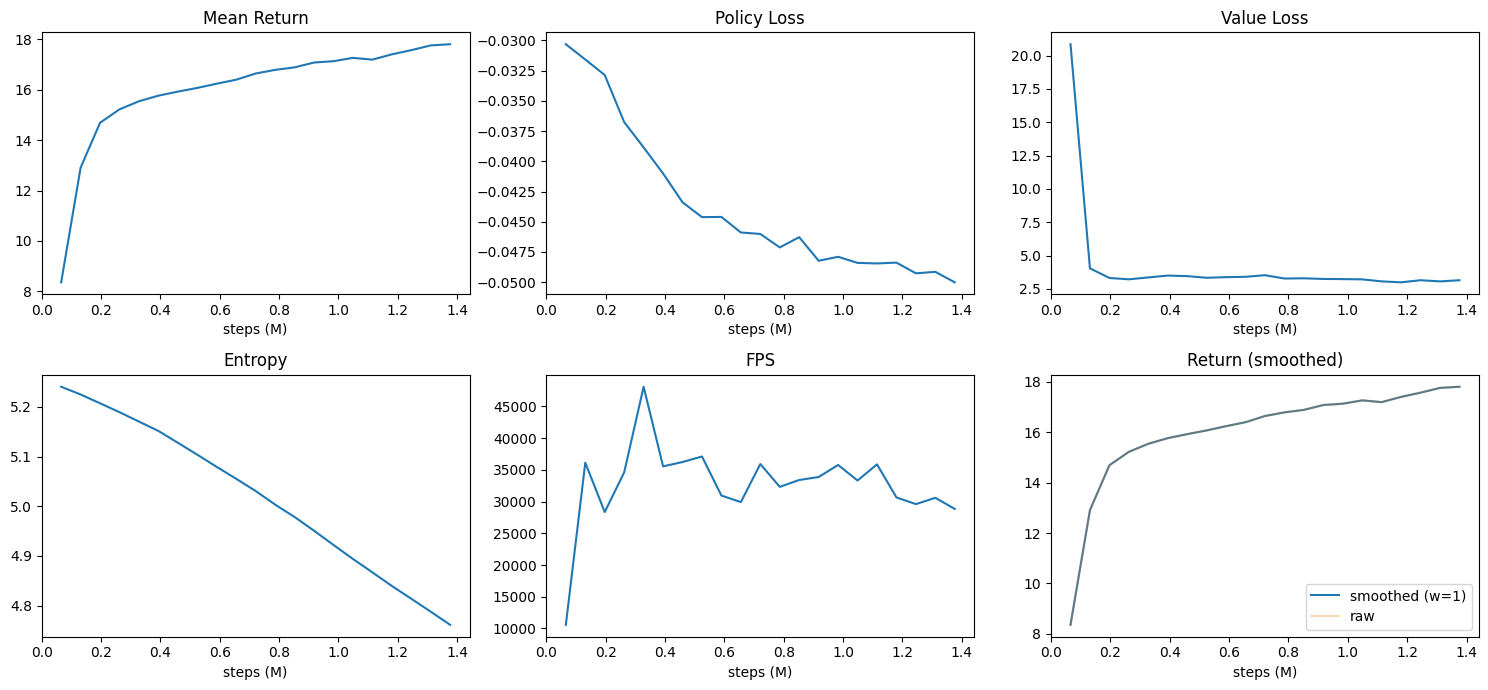

best return: 17.80  after 1.4M steps


In [11]:
steps  = [h['global_step'] / 1e6 for h in history]
rets   = [h['mean_ret']    for h in history]
pg     = [h['pg']          for h in history]
vf     = [h['vf']          for h in history]
ent    = [h['ent']         for h in history]
fps_h  = [h['fps']         for h in history]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

axes[0,0].plot(steps, rets);  axes[0,0].set_title('Mean Return');    axes[0,0].set_xlabel('steps (M)')
axes[0,1].plot(steps, pg);    axes[0,1].set_title('Policy Loss');    axes[0,1].set_xlabel('steps (M)')
axes[0,2].plot(steps, vf);    axes[0,2].set_title('Value Loss');     axes[0,2].set_xlabel('steps (M)')
axes[1,0].plot(steps, ent);   axes[1,0].set_title('Entropy');        axes[1,0].set_xlabel('steps (M)')
axes[1,1].plot(steps, fps_h); axes[1,1].set_title('FPS');            axes[1,1].set_xlabel('steps (M)')

# smooth return
window = max(1, len(rets) // 20)
smooth = np.convolve(rets, np.ones(window)/window, mode='valid')
axes[1,2].plot(steps[window-1:], smooth, label=f'smoothed (w={window})')
axes[1,2].plot(steps, rets, alpha=0.3, label='raw')
axes[1,2].set_title('Return (smoothed)'); axes[1,2].set_xlabel('steps (M)'); axes[1,2].legend()

plt.tight_layout()
plt.show()
print(f"best return: {best_mean_ret:.2f}  after {global_step/1e6:.1f}M steps")

## Evaluate best policy — draw the found graph

edge counts: [23, 23, 23, 23, 23, 23, 23, 23]  max=23


/tmp/ipykernel_16684/2237915731.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


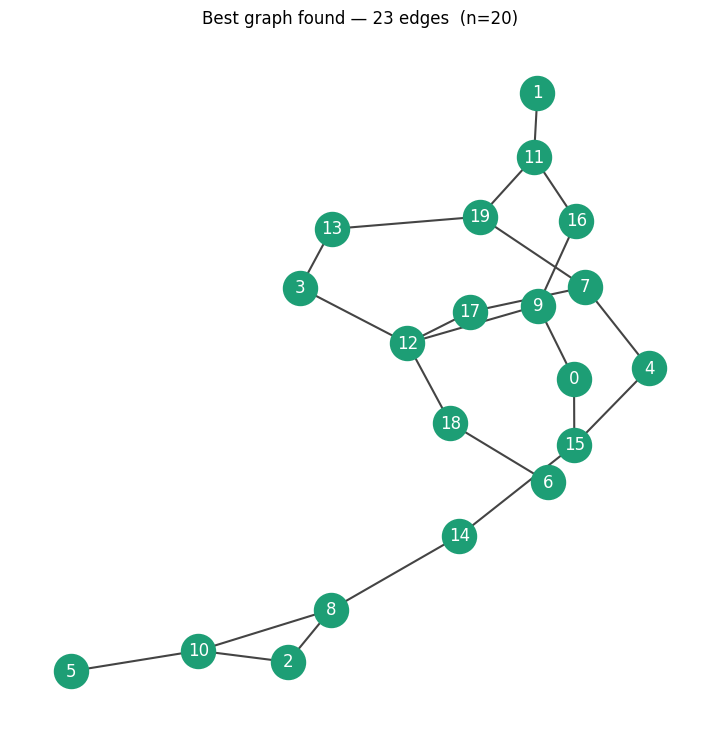

In [12]:
import networkx as nx

# load best checkpoint for eval (uses the policy already in memory if training just ran)
# policy, _, cfg_ck, *_ = load_checkpoint('./checkpoints/best.pt')

policy.eval()
adjs = run_episodes(policy, cfg, n_episodes=8, deterministic=True)

edge_counts = [int(adj.sum()) // 2 for adj in adjs]
print(f"edge counts: {edge_counts}  max={max(edge_counts)}")

# draw the densest graph found
best_adj = adjs[np.argmax(edge_counts)]
G   = nx.from_numpy_array(best_adj)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(7, 7))
nx.draw(G, pos, with_labels=True,
        node_color='#1D9E75', node_size=600,
        font_color='white', edge_color='#444', width=1.5)
plt.title(f"Best graph found — {max(edge_counts)} edges  (n={cfg['n']})")
plt.tight_layout()
plt.show()